In [1]:
import numpy as np
import random
from itertools import combinations
from pprint import pprint

# Типы агентов
AGENT_TYPES = ["ground", "aerial", "amphibious"]

# Фиксация генератора случайных чисел
random.seed(42)
np.random.seed(42)

def generate_agent(agent_id):
    features = {
        "power": round(random.uniform(0.5, 1.5), 2),
        "coverage": round(random.uniform(0.2, 1.0), 2),
        "mobility": round(random.uniform(0.0, 1.0), 2)
    }
    cost = round(random.uniform(1.0, 3.0), 2)
    agent_type = random.choice(AGENT_TYPES)
    
    return {
        "id": agent_id,
        "features": features,
        "cost": cost,
        "type": agent_type
    }

def generate_agents(n):
    return [generate_agent(i) for i in range(n)]

# Генерируем агентов
agents = generate_agents(5)
pprint(agents)

[{'cost': 1.45,
  'features': {'coverage': 0.22, 'mobility': 0.28, 'power': 1.14},
  'id': 0,
  'type': 'amphibious'},
 {'cost': 2.18,
  'features': {'coverage': 0.79, 'mobility': 0.55, 'power': 0.6},
  'id': 1,
  'type': 'ground'},
 {'cost': 1.05,
  'features': {'coverage': 0.37, 'mobility': 0.51, 'power': 0.53},
  'id': 2,
  'type': 'ground'},
 {'cost': 1.9,
  'features': {'coverage': 0.76, 'mobility': 0.42, 'power': 1.22},
  'id': 3,
  'type': 'aerial'},
 {'cost': 2.4,
  'features': {'coverage': 0.21, 'mobility': 0.81, 'power': 1.31},
  'id': 4,
  'type': 'aerial'}]


In [2]:
def feature_vector(agent):
    f = agent["features"]
    return np.array([f["power"], f["coverage"], f["mobility"]])

def cosine_similarity(x, y):
    norm_product = np.linalg.norm(x) * np.linalg.norm(y)
    return float(np.dot(x, y)) / norm_product if norm_product > 0 else 0.0

In [3]:
def coalition_value(coalition, weight_vector=None, synergy_lambda=0.5):
    if weight_vector is None:
        weight_vector = np.array([1.0, 1.0, 1.0])  # Равные веса по умолчанию

    # Базовая сумма (вклад агентов)
    value = 0.0
    agent_vectors = {}
    
    for agent in coalition:
        x = feature_vector(agent)
        agent_vectors[agent["id"]] = x
        value += np.dot(weight_vector, x)
    
    # Синергия
    for a1, a2 in combinations(coalition, 2):
        x1 = agent_vectors[a1["id"]]
        x2 = agent_vectors[a2["id"]]
        gamma = synergy_lambda * cosine_similarity(x1, x2)
        value += gamma

    return round(value, 3)

In [4]:
# Пример: агенты 0, 1 и 2 образуют коалицию
example_coalition = [agents[0], agents[1], agents[2]]
v = coalition_value(example_coalition)
print(f"Ценность коалиции из агентов {[a['id'] for a in example_coalition]}: {v}")

Ценность коалиции из агентов [0, 1, 2]: 6.262


In [5]:
from itertools import chain, combinations

def powerset(agents):
    """Возвращает все возможные непустые коалиции"""
    agent_list = list(agents)
    return list(chain.from_iterable(combinations(agent_list, r) 
                                    for r in range(1, len(agent_list) + 1)))

# Получим все коалиции
coalitions = powerset(agents)
print(f"Сгенерировано {len(coalitions)} коалиций.")

# Пример: первая коалиция
for i, c in enumerate(coalitions[:5]):
    print(f"Коалиция {i+1}: {[a['id'] for a in c]}")

Сгенерировано 31 коалиций.
Коалиция 1: [0]
Коалиция 2: [1]
Коалиция 3: [2]
Коалиция 4: [3]
Коалиция 5: [4]


In [6]:
coalition_values = []

for c in coalitions:
    value = coalition_value(list(c), synergy_lambda=0.7)  # λ можно варьировать
    ids = [agent["id"] for agent in c]
    coalition_values.append({
        "agents": ids,
        "value": value
    })

# Пример вывода
for entry in coalition_values[:5]:
    print(entry)

{'agents': [0], 'value': 1.64}
{'agents': [1], 'value': 1.94}
{'agents': [2], 'value': 1.41}
{'agents': [3], 'value': 2.4}
{'agents': [4], 'value': 2.33}


In [7]:
# Создаём быстрый доступ к ценности коалиций по их составу
coalition_map = {
    frozenset(entry["agents"]): entry["value"]
    for entry in coalition_values
}

In [8]:
import math

def shapley_value(agent_id, agents, coalition_map):
    n = len(agents)
    other_agents = [a["id"] for a in agents if a["id"] != agent_id]
    total = 0.0

    for r in range(len(other_agents)+1):
        for S_ids in combinations(other_agents, r):
            S = set(S_ids)
            S_with_i = S | {agent_id}
            
            v_S = coalition_map.get(frozenset(S), 0.0)
            v_Si = coalition_map.get(frozenset(S_with_i), 0.0)
            marginal = v_Si - v_S

            weight = math.factorial(len(S)) * math.factorial(n - len(S) - 1) / math.factorial(n)
            total += weight * marginal

    return round(total, 4)

In [9]:
shapley_vector = []

for agent in agents:
    phi = shapley_value(agent["id"], agents, coalition_map)
    shapley_vector.append({
        "agent_id": agent["id"],
        "shapley_value": phi
    })

print("Вектор Шепли:")
for entry in shapley_vector:
    print(entry)

Вектор Шепли:
{'agent_id': 0, 'shapley_value': 2.8574}
{'agent_id': 1, 'shapley_value': 3.1349}
{'agent_id': 2, 'shapley_value': 2.6869}
{'agent_id': 3, 'shapley_value': 3.6898}
{'agent_id': 4, 'shapley_value': 3.58}


In [10]:
import pandas as pd

def extract_features(agent, coalition):
    agent_x = feature_vector(agent)

    if coalition:
        coalition_vectors = [feature_vector(a) for a in coalition]
        coalition_sum = np.sum(coalition_vectors, axis=0)
        coalition_avg = coalition_sum / len(coalition)
    else:
        coalition_avg = np.zeros_like(agent_x)

    return {
        "agent_id": agent["id"],
        "agent_power": agent_x[0],
        "agent_coverage": agent_x[1],
        "agent_mobility": agent_x[2],
        "coalition_size": len(coalition),
        "coalition_avg_power": coalition_avg[0],
        "coalition_avg_coverage": coalition_avg[1],
        "coalition_avg_mobility": coalition_avg[2]
    }

In [11]:
dataset = []

for agent in agents:
    agent_id = agent["id"]
    other_agents = [a for a in agents if a["id"] != agent_id]

    for r in range(len(other_agents)+1):
        for S in combinations(other_agents, r):
            S_ids = [a["id"] for a in S]
            S_with_i = S_ids + [agent_id]

            v_S = coalition_map.get(frozenset(S_ids), 0.0)
            v_Si = coalition_map.get(frozenset(S_with_i), 0.0)
            marginal = v_Si - v_S

            features = extract_features(agent, list(S))
            phi = shapley_value(agent_id, agents, coalition_map)

            features["marginal_contrib"] = round(marginal, 4)
            features["shapley_value"] = phi

            dataset.append(features)

In [12]:
df = pd.DataFrame(dataset)
print(df.head())

# Сохраняем в CSV
df.to_csv("shapley_dataset.csv", index=False)

   agent_id  agent_power  agent_coverage  agent_mobility  coalition_size  \
0         0         1.14            0.22            0.28               0   
1         0         1.14            0.22            0.28               1   
2         0         1.14            0.22            0.28               1   
3         0         1.14            0.22            0.28               1   
4         0         1.14            0.22            0.28               1   

   coalition_avg_power  coalition_avg_coverage  coalition_avg_mobility  \
0                 0.00                    0.00                    0.00   
1                 0.60                    0.79                    0.55   
2                 0.53                    0.37                    0.51   
3                 1.22                    0.76                    0.42   
4                 1.31                    0.21                    0.81   

   marginal_contrib  shapley_value  
0             1.640         2.8574  
1             2.163     

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
# Если запускаем с нуля
df = pd.read_csv("shapley_dataset.csv")

# Отбираем признаки и таргет
features = [
    "agent_power", "agent_coverage", "agent_mobility",
    "coalition_size",
    "coalition_avg_power", "coalition_avg_coverage", "coalition_avg_mobility"
]

X = df[features].values
y = df["shapley_value"].values

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Линейная регрессия как базовая модель
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
print(f"Коэффициент детерминации (R²): {r2:.4f}")

Среднеквадратичная ошибка (MSE): 0.0018
Коэффициент детерминации (R²): 0.9835


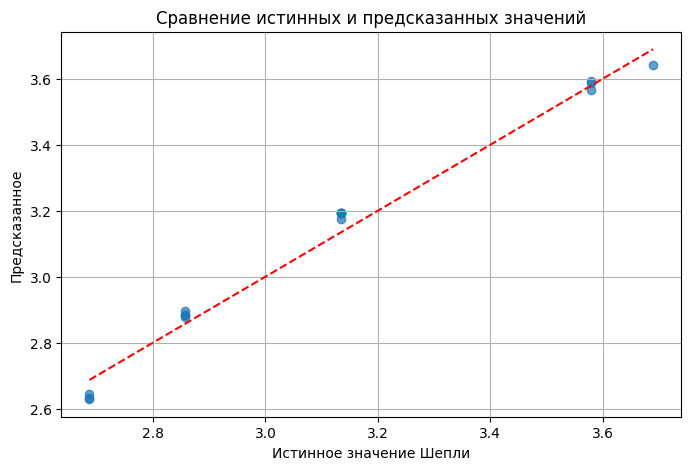

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Истинное значение Шепли")
plt.ylabel("Предсказанное")
plt.title("Сравнение истинных и предсказанных значений")
plt.grid(True)
plt.show()

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("shapley_dataset.csv")

features = [
    "agent_power", "agent_coverage", "agent_mobility",
    "coalition_size",
    "coalition_avg_power", "coalition_avg_coverage", "coalition_avg_mobility"
]

X = df[features]
y = df["shapley_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
import xgboost as xgb
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [20]:
y_pred = model_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"XGBoost MSE: {mse:.4f}")
print(f"XGBoost R²: {r2:.4f}")

XGBoost MSE: 0.0000
XGBoost R²: 1.0000


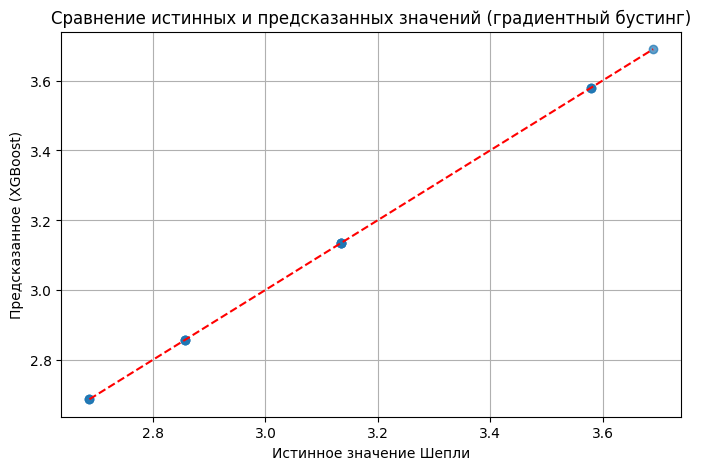

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Истинное значение Шепли")
plt.ylabel("Предсказанное (XGBoost)")
plt.title("Сравнение истинных и предсказанных значений (градиентный бустинг)")
plt.grid(True)
plt.show()

In [22]:
def monte_carlo_shapley(agent_id, agents, coalition_map, m=100):
    n = len(agents)
    all_ids = [a["id"] for a in agents if a["id"] != agent_id]
    marginal_contribs = []

    for _ in range(m):
        S = random.sample(all_ids, random.randint(0, len(all_ids)))
        S_ids = set(S)
        S_with_i = S_ids | {agent_id}

        v_S = coalition_map.get(frozenset(S_ids), 0.0)
        v_Si = coalition_map.get(frozenset(S_with_i), 0.0)
        marginal_contribs.append(v_Si - v_S)

    return round(np.mean(marginal_contribs), 4)

In [23]:
results = []

for agent in agents:
    true_phi = shapley_value(agent["id"], agents, coalition_map)
    approx_mc = monte_carlo_shapley(agent["id"], agents, coalition_map, m=200)

    X_row = pd.DataFrame([extract_features(agent, [a for a in agents if a["id"] != agent["id"]])])
    ml_pred = model_xgb.predict(X_row[features])[0]

    results.append({
        "agent_id": agent["id"],
        "true_phi": true_phi,
        "ml_pred": round(ml_pred, 4),
        "mc_approx": approx_mc,
        "ml_error": abs(ml_pred - true_phi),
        "mc_error": abs(approx_mc - true_phi)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)

   agent_id  true_phi  ml_pred  mc_approx  ml_error  mc_error
0         0    2.8574   2.8575     2.7946  0.000080    0.0628
1         1    3.1349   3.1349     3.2225  0.000013    0.0876
2         2    2.6869   2.6871     2.7142  0.000228    0.0273
3         3    3.6898   3.6896     3.7210  0.000229    0.0312
4         4    3.5800   3.5800     3.5366  0.000014    0.0434


In [24]:
ml_mae = np.mean(comparison_df["ml_error"])
mc_mae = np.mean(comparison_df["mc_error"])

print(f"Средняя абсолютная ошибка (MAE):")
print(f"  Модель ML:       {ml_mae:.4f}")
print(f"  Монте-Карло:     {mc_mae:.4f}")

Средняя абсолютная ошибка (MAE):
  Модель ML:       0.0001
  Монте-Карло:     0.0505


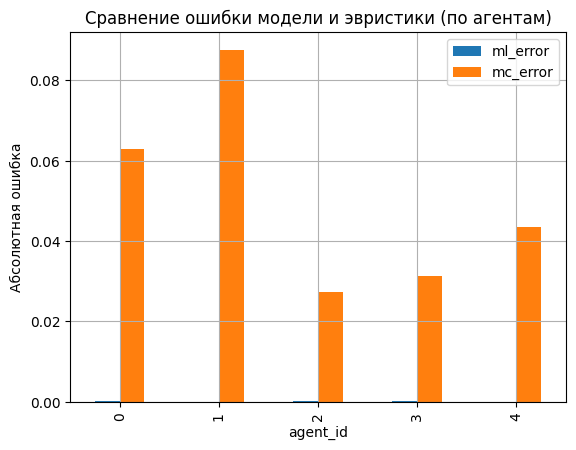

In [25]:
import matplotlib.pyplot as plt

comparison_df[["agent_id", "ml_error", "mc_error"]].set_index("agent_id").plot.bar()
plt.ylabel("Абсолютная ошибка")
plt.title("Сравнение ошибки модели и эвристики (по агентам)")
plt.grid(True)
plt.show()

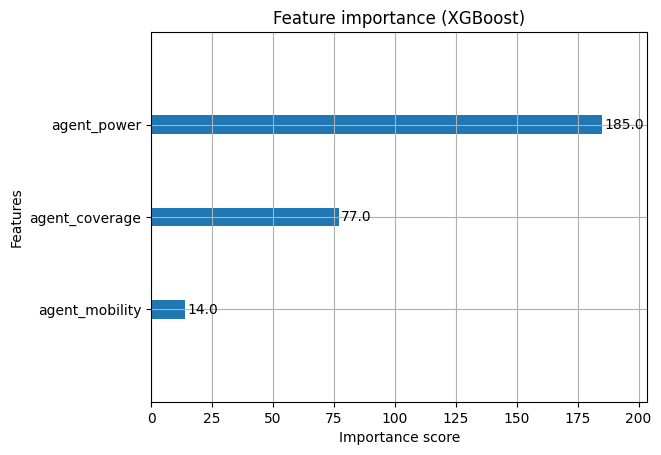

In [26]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model_xgb)
plt.title("Feature importance (XGBoost)")
plt.savefig("feature_importance.png", bbox_inches='tight')

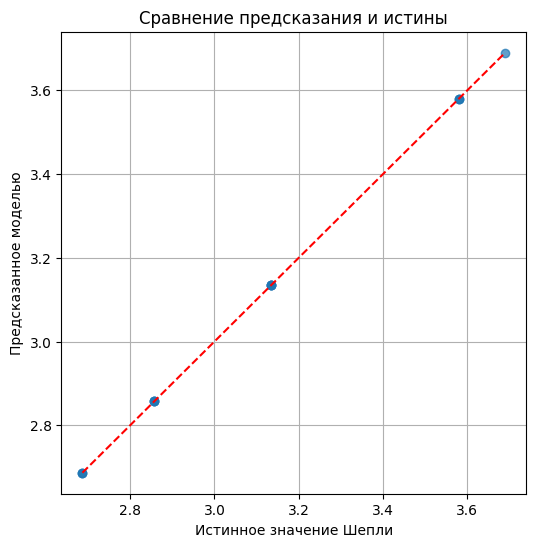

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Истинное значение Шепли")
plt.ylabel("Предсказанное моделью")
plt.title("Сравнение предсказания и истины")
plt.grid(True)
plt.savefig("shapley_scatter.png", bbox_inches='tight')
